<a href="https://colab.research.google.com/github/mhines2/lego-resale-model/blob/main/p8_lego_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [122]:
# ----------------------------------------------
# Import Required Libraries
# ----------------------------------------------

import os
import pandas as pd
import seaborn as sns
import sklearn.model_selection
import sklearn.preprocessing
import sklearn.neighbors
import sklearn.metrics
import sklearn.datasets
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from scipy.spatial.distance import pdist, squareform, cdist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import distance
from google.colab import files

In [123]:
# ----------------------------------------------
# Upload and Load the Dataset
# ----------------------------------------------

print("Please upload your sets.csv file:")
uploaded = files.upload()
lego_df2 = pd.read_csv("sets.csv")
print("Columns in original dataset:")
print(lego_df2.columns)

Please upload your sets.csv file:


Saving sets.csv to sets.csv
Columns in original dataset:
Index(['Set_ID', 'Name', 'Year', 'Theme', 'Theme_Group', 'Subtheme',
       'Category', 'Packaging', 'Num_Instructions', 'Availability', 'Pieces',
       'Minifigures', 'Owned', 'Rating', 'USD_MSRP', 'Total_Quantity',
       'Current_Price'],
      dtype='object')


In [124]:
# ----------------------------------------------
# Data Cleaning and Preprocessing
# ----------------------------------------------

sdf = lego_df2.dropna(subset=['USD_MSRP', 'Current_Price', 'Pieces', 'Theme'])

df = sdf.drop([
    "Set_ID", "Theme_Group", "Subtheme", "Category", "Packaging",
    "Num_Instructions", "Total_Quantity", "Minifigures", "Availability",
    "Owned", "Rating"
], axis=1)

df.to_csv('reduced_lego_data.csv', index=False)
print("Cleaned dataset saved as 'reduced_lego_data.csv'.")

df = pd.read_csv("reduced_lego_data.csv")
print("First 5 rows of the cleaned dataset:")
print(df.head())


Cleaned dataset saved as 'reduced_lego_data.csv'.
First 5 rows of the cleaned dataset:
                              Name  Year   Theme  Pieces  USD_MSRP  \
0                   Straight Rails  1991  Trains     8.0     12.99   
1                     Curved Rails  1991  Trains     8.0     12.99   
2         Manual Points with Track  1991  Trains     6.0     27.99   
3  Transformer and Speed Regulator  1991  Trains     3.0     41.99   
4             Large Building Plate  1992   Duplo     1.0     14.99   

   Current_Price  
0        50.4242  
1        16.0000  
2        28.0000  
3        60.0000  
4         7.0000  



Most Popular Values for Key Attributes:
Name: Star Wars Advent Calendar
Year: 2019
Theme: Star Wars
Pieces: 1.0
USD_MSRP: 9.99
Current_Price: 20.0


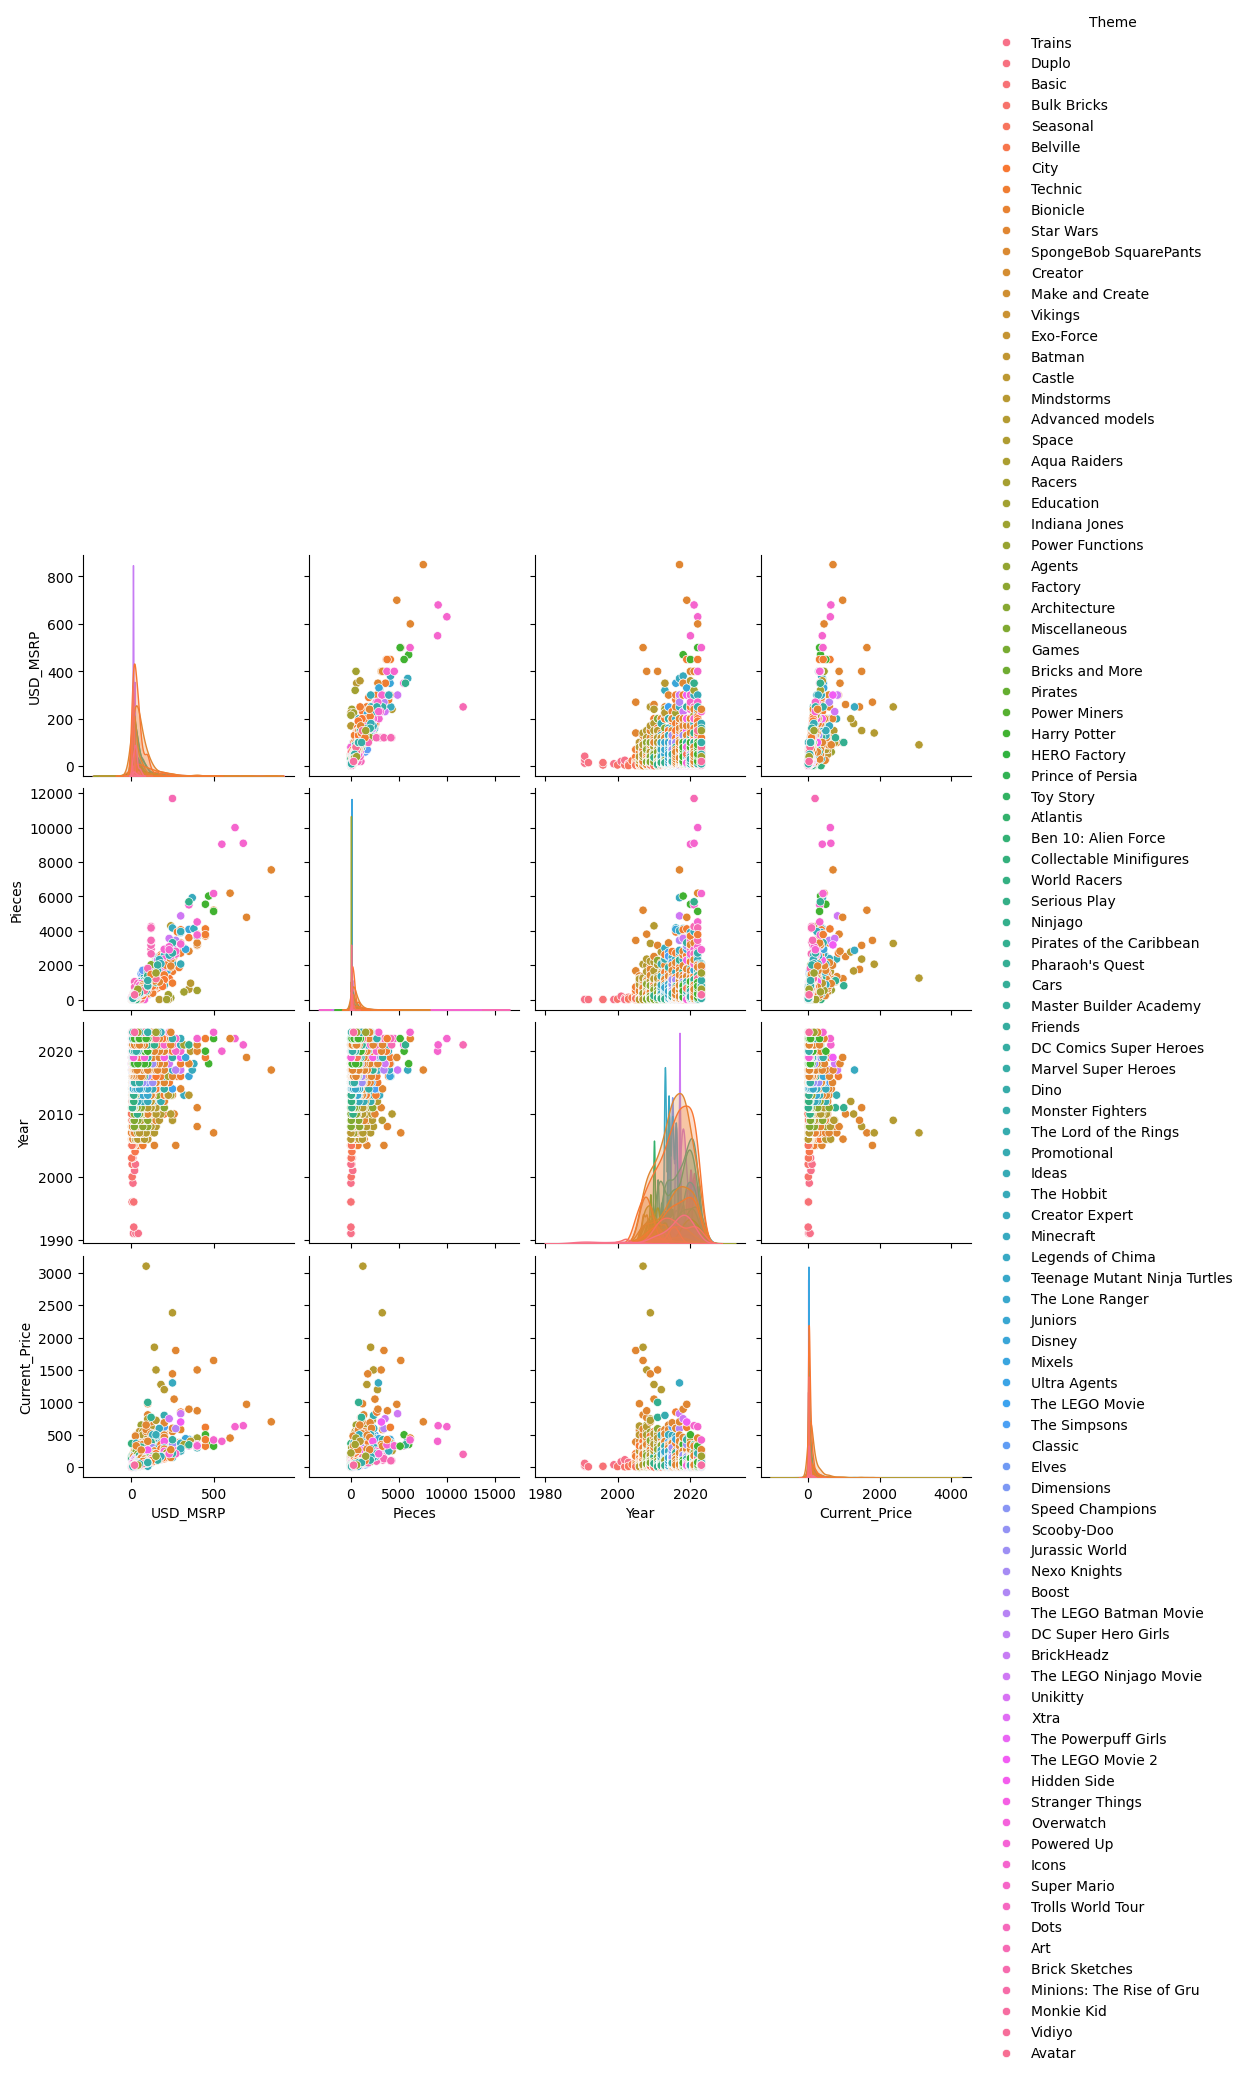

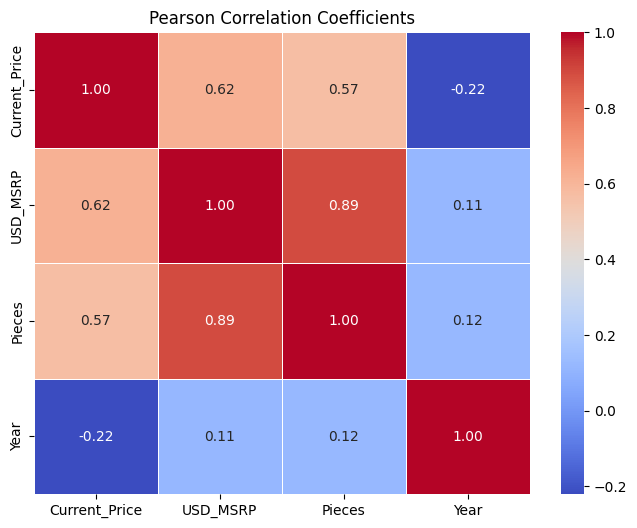

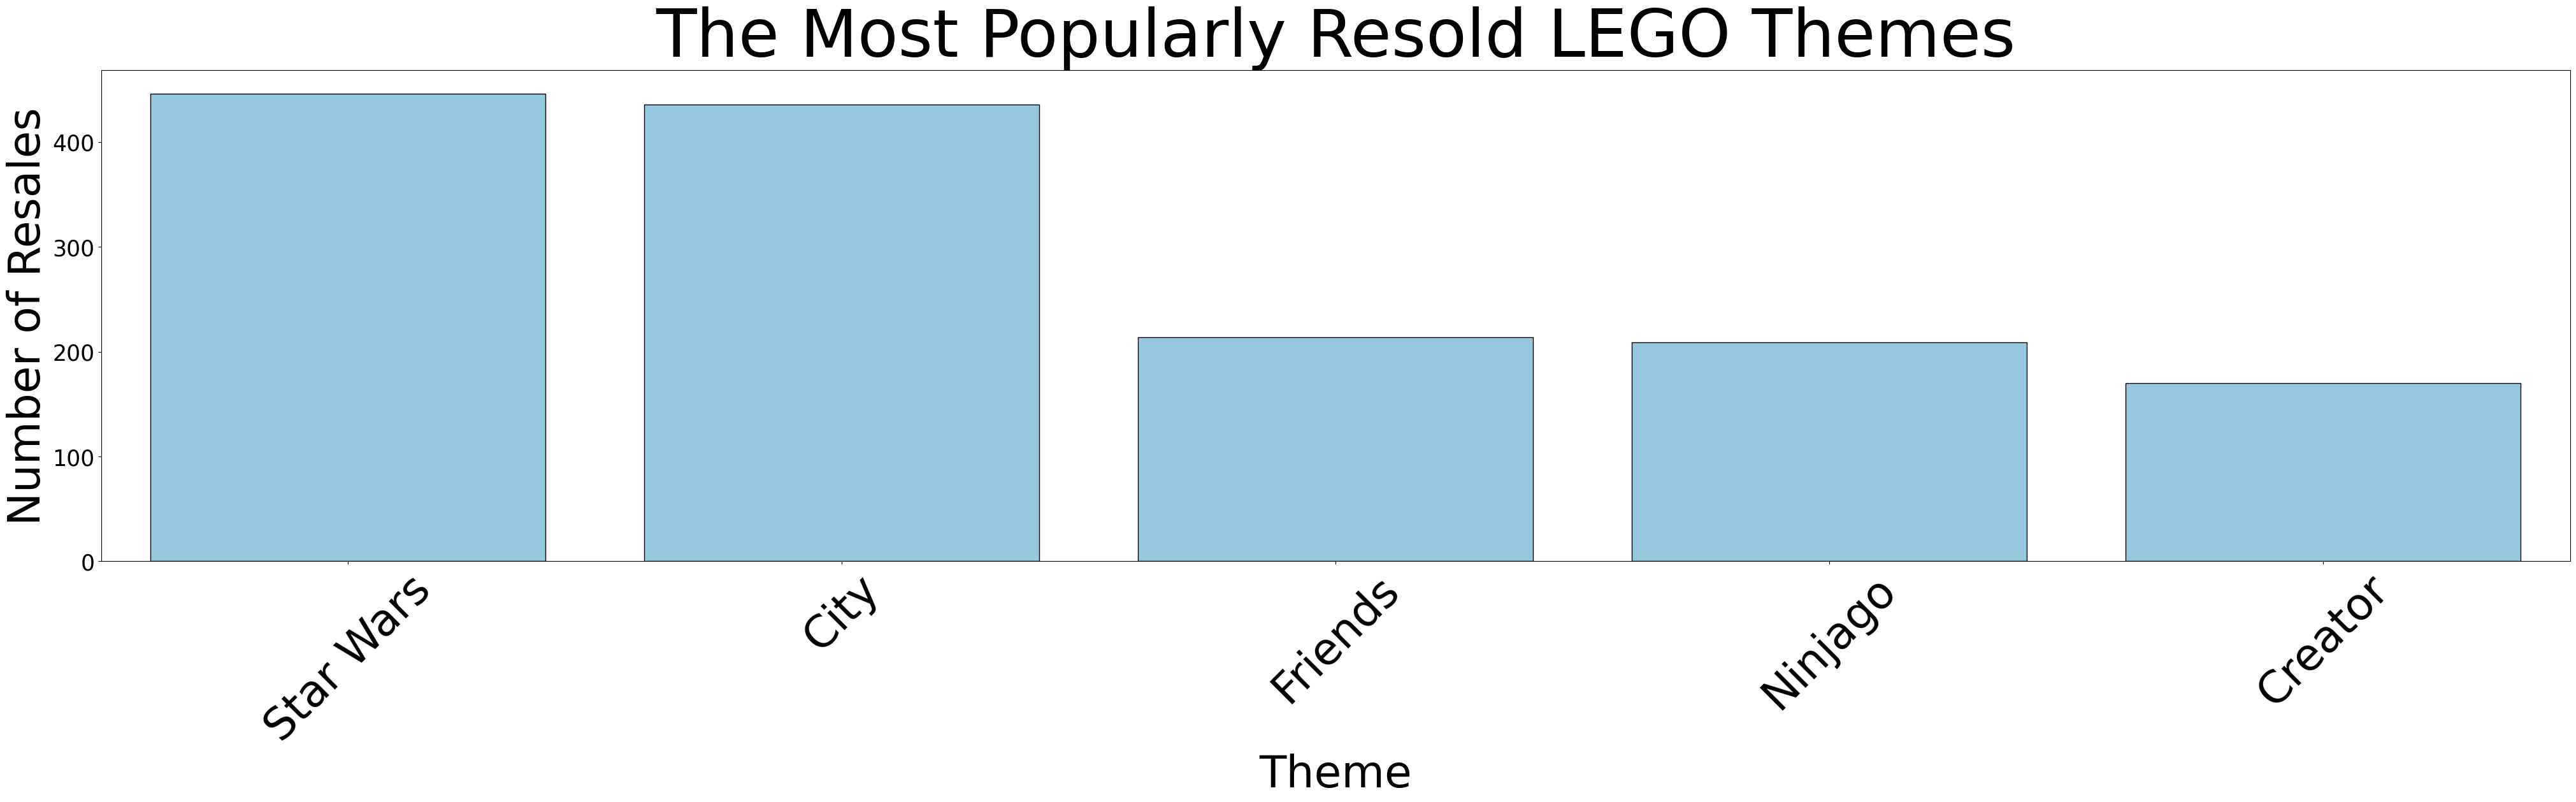

In [125]:
# ----------------------------------------------
# Exploratory Data Analysis
# ----------------------------------------------

key_attributes = ["Name", "Year", "Theme", "Pieces", "USD_MSRP", "Current_Price"]
most_popular_values = {col: df[col].mode()[0] for col in key_attributes if col in df.columns}
print("\nMost Popular Values for Key Attributes:")
for attr, value in most_popular_values.items():
    print(f"{attr}: {value}")

# Create pairplot to visualize relationships between numeric features by Theme
sns.pairplot(df, hue="Theme", vars=['USD_MSRP', 'Pieces', 'Year', 'Current_Price'])

# Compute Pearson correlation matrix for selected numerical features
reduced = df[["Current_Price", "USD_MSRP", "Pieces", "Year"]]
heat = reduced.corr(numeric_only=True)

# Visualize correlation matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(heat, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Coefficients")

# Create new columns for price per piece and appreciation ratio
df["Price_per_piece"] = df["USD_MSRP"] / df["Pieces"]
df["Price_appreciation"] = df["Current_Price"] / df["USD_MSRP"]

# Plot popular themes (threshold: 150+ sets)
plt.figure(figsize=(50, 10))
plt.title("The Most Popularly Resold LEGO Themes", fontsize=75)
themes = df['Theme'].value_counts()
popular = themes[themes >= 150]
sns.barplot(x=popular.index, y=popular.values, color="skyblue", edgecolor="black")
plt.xlabel("Theme", fontsize=50)
plt.ylabel("Number of Resales", fontsize=50)
plt.xticks(rotation=45, fontsize=50)
plt.yticks(fontsize=25)
plt.show()
plt.close()

,Year,Pieces,USD_MSRP,Current_Price,Price_per_piece,Price_appreciation
count,3607.000000,3607.000000,3607.000000,3607.000000,3607.000000,3607.000000
mean,2015.704186,444.148877,46.279795,86.038420,inf,2.174147
std,4.590598,714.511411,61.502246,146.239004,NaN,4.000611
min,1991.000000,0.000000,1.990000,0.050000,0.019221,0.020080
25%,2013.000000,92.000000,12.990000,19.990000,0.089641,0.996180
50%,2016.000000,233.000000,29.990000,40.000000,0.109853,1.500167
75%,2019.000000,514.000000,49.990000,95.000000,0.145912,2.500834
max,2023.000000,11695.000000,849.990000,3099.990000,inf,183.417085


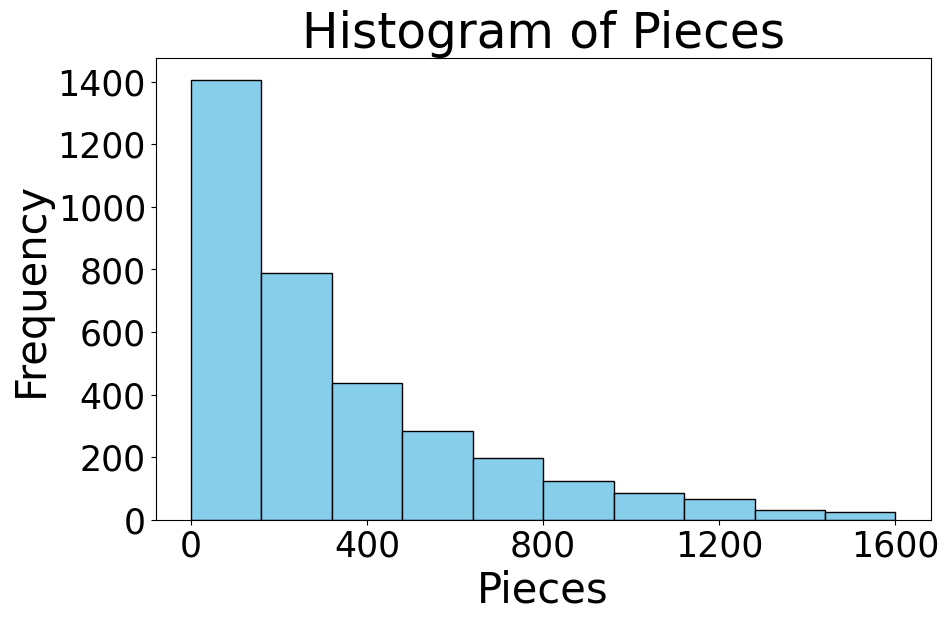

,Pieces
count,3607.000000
mean,444.148877
std,714.511411
min,0.000000
25%,92.000000
50%,233.000000
75%,514.000000
max,11695.000000


np.int64(72)

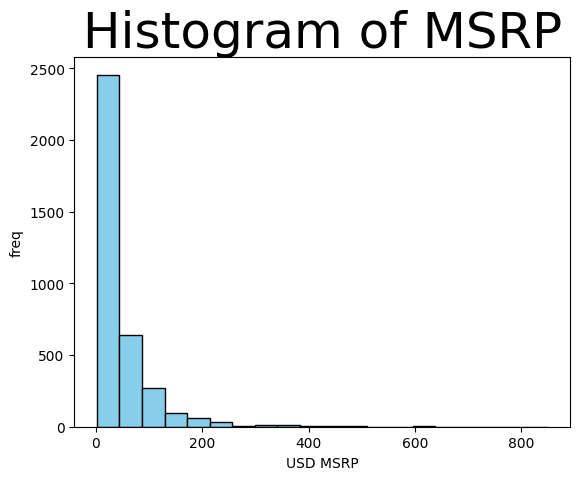

,USD_MSRP
count,3607.000000
mean,46.279795
std,61.502246
min,1.990000
25%,12.990000
50%,29.990000
75%,49.990000
max,849.990000


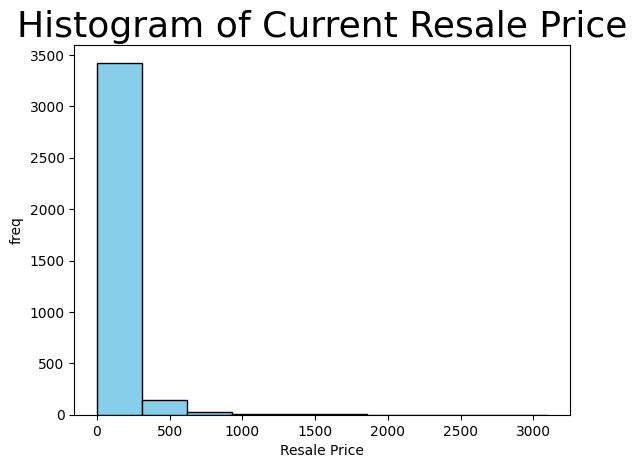

,Current_Price
count,3607.000000
mean,86.038420
std,146.239004
min,0.050000
25%,19.990000
50%,40.000000
75%,95.000000
max,3099.990000


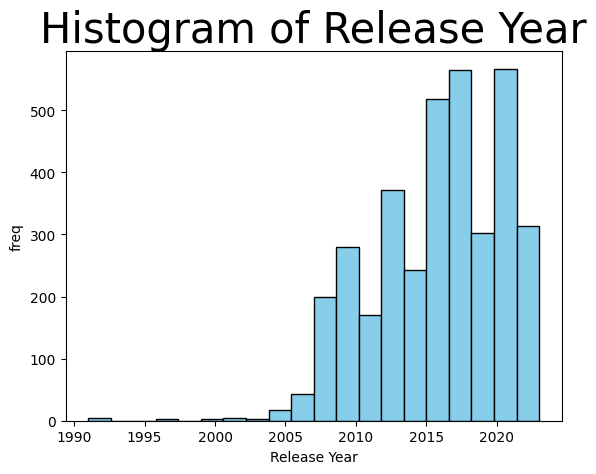

,Year
count,3607.000000
mean,2015.704186
std,4.590598
min,1991.000000
25%,2013.000000
50%,2016.000000
75%,2019.000000
max,2023.000000


In [126]:
# ----------------------------------------------
# Histograms for Numeric Features
# ----------------------------------------------

# Display overall statistics of numeric features (mean, median, etc.)
display(df.describe())

# Pieces Histogram
plt.figure(figsize=(10, 6))
plt.xticks(np.arange(0, 12000, 400), fontsize=25)
plt.yticks(fontsize=25)
plt.ylabel('Frequency', fontsize=30)
plt.xlabel('Pieces', fontsize=30)
plt.title("Histogram of Pieces", fontsize=35)
pieces = df['Pieces']
plt.hist(pieces, bins=10, color='skyblue', edgecolor='black', range=(0, 1600))
plt.show()
plt.close()
display(pieces.describe())

# Count how many sets have large number of pieces
display(pieces[pieces > 2586].count())

# MSRP Histogram
plt.ylabel('freq')
plt.xlabel('USD MSRP')
msrp = df['USD_MSRP']
plt.hist(msrp, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of MSRP", fontsize=36)
plt.show()
plt.close()
display(msrp.describe())

# Current Price Histogram
plt.ylabel('freq')
plt.xlabel('Resale Price')
current = df['Current_Price']
plt.title("Histogram of Current Resale Price", fontsize=26)
plt.hist(current, bins=10, color='skyblue', edgecolor='black')
plt.show()
plt.close()
display(current.describe())

# Year Histogram
plt.ylabel('freq')
plt.xlabel('Release Year')
years = df['Year']
plt.hist(years, bins=20, color='skyblue', edgecolor='black')
plt.title("Histogram of Release Year", fontsize=30)
plt.show()
plt.close()
display(years.describe())

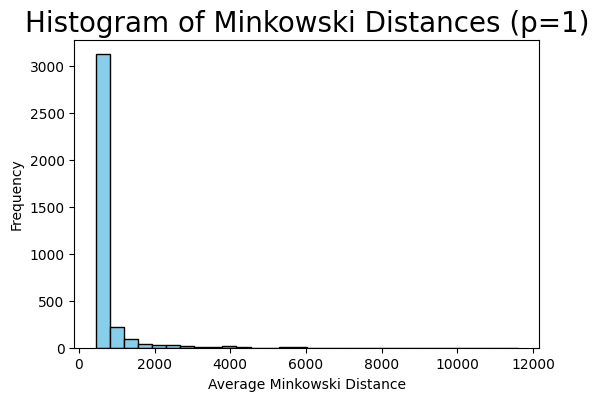

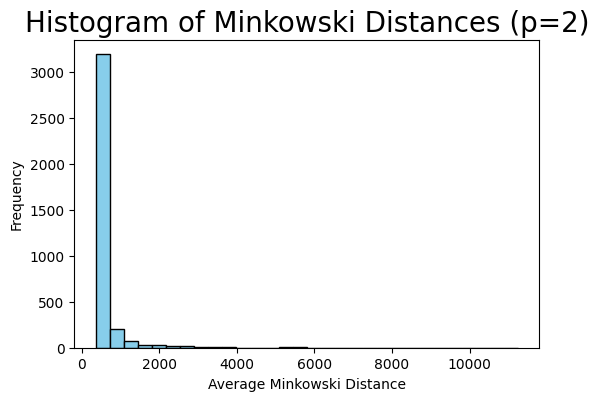

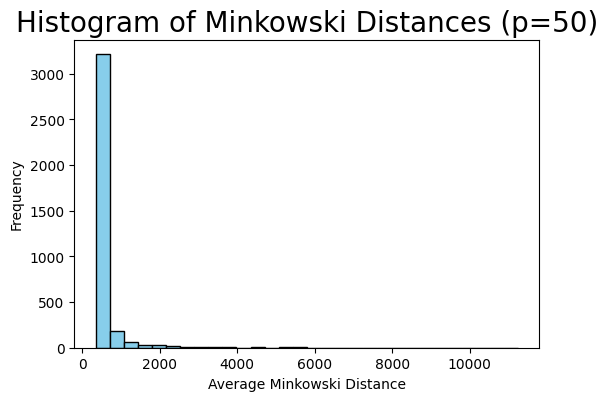

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'berlin', 'managua', 'vanimo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 't

Text(0.5, 1.0, 'Cosine Similarity Score of Ten Sampled Points')

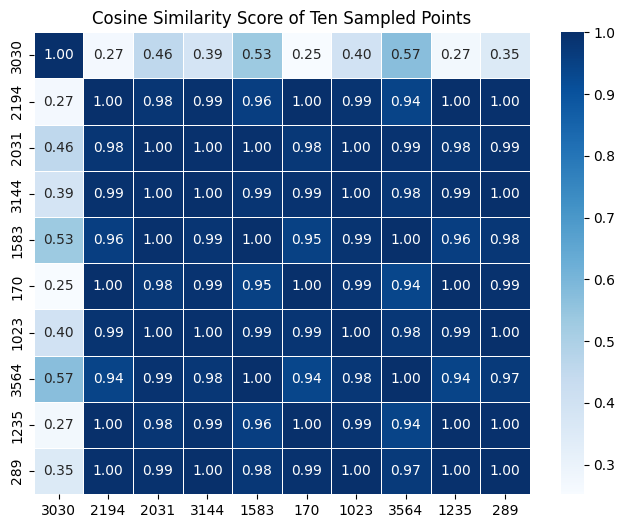

In [127]:
# ----------------------------------------------
# Distance and Similarity Measures
# ----------------------------------------------

# Minkowski Distance Matrix
numerical = df[['Pieces', 'USD_MSRP', 'Current_Price']]
minks = (1, 2, 50)
for j in minks:
    distances = squareform(pdist(numerical, metric='minkowski', p=j))
    averages = [np.mean(point) for point in distances]
    plt.figure(figsize=(6, 4))
    plt.hist(averages, bins=30, color='skyblue', edgecolor='black')
    plt.xlabel('Average Minkowski Distance')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Minkowski Distances (p={j})', fontsize=20)
    plt.show()

# Cosine Similarity (10 random sampled rows)
sample = df.sample(n=10, random_state=42)
sample_num = sample[['Year', 'Pieces', 'USD_MSRP', 'Current_Price']].values
cosine_dist_matrix = cdist(sample_num, sample_num, metric='cosine')
cosine_dist_df = pd.DataFrame(cosine_dist_matrix, index=sample.index, columns=sample.index)
heat = 1 - cosine_dist_df
plt.figure(figsize=(8, 6))
print(list(plt.colormaps))
sns.heatmap(heat, annot=True, cmap="Blues", fmt=".2f", linewidths=0.5)
plt.title('Cosine Similarity Score of Ten Sampled Points')

In [128]:
# ----------------------------------------------
# Encoding & Feature Setup
# ----------------------------------------------

df_encoded = pd.get_dummies(df, columns=['Theme'], drop_first=True)
data = df_encoded.drop(columns=['Name'])
X = data.drop(columns=['Current_Price', 'Price_appreciation', 'Price_per_piece'])
y = data['Current_Price']

,Name,Year,Theme,Pieces,USD_MSRP,Current_Price
0,Straight Rails,1991,Trains,8.0,12.99,50.4242
1,Curved Rails,1991,Trains,8.0,12.99,16.0000
2,Manual Points with Track,1991,Trains,6.0,27.99,28.0000
3,Transformer and Speed Regulator,1991,Trains,3.0,41.99,60.0000
4,Large Building Plate,1992,Duplo,1.0,14.99,7.0000
...,...,...,...,...,...,...
3602,2 Fast 2 Furious Nissan Skyline GT-R (R34),2023,Speed Champions,319.0,24.99,14.6400
3603,Fighter Plane Chase,2023,Indiana Jones,387.0,34.99,27.8900
3604,Escape from the Lost Tomb,2023,Indiana Jones,600.0,39.99,33.1000
3605,Temple of the Golden Idol,2023,Indiana Jones,1545.0,149.99,170.1470


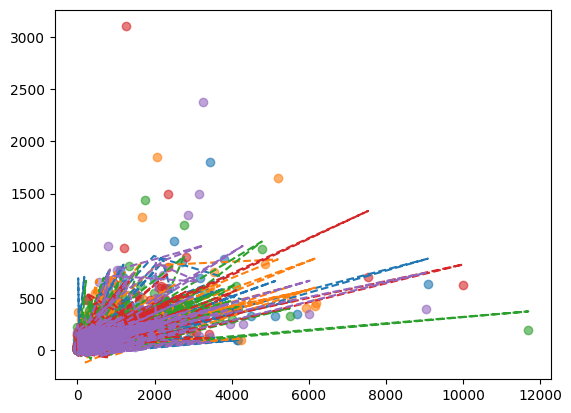

In [129]:
# ----------------------------------------------
# 5-Fold Cross Validation (Linear Regression)
# ----------------------------------------------

kf = sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
model = LinearRegression()
mses, rses, maes = [], [], []

for fold, (train_index, test_index) in enumerate(kf.split(X), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mses.append(mse)
    mae = mean_absolute_error(y_test, y_pred)
    maes.append(mae)
    rses.append(model.score(X_train, y_train))
    plt.scatter(X_test['Pieces'], y_test, label=f'Fold {fold} Actual', alpha=0.6)
    plt.plot(X_test['Pieces'], y_pred, label=f'Fold {fold} Predicted', linestyle='--')

# Clean-up extra columns
df.drop(columns=['Price_per_piece', 'Price_appreciation'])

In [130]:
# ----------------------------------------------
# Train/Test Split and Cross-Validation Setup
# ----------------------------------------------

# Re-encode and prepare input features and labels
data = pd.get_dummies(df, columns=['Theme'])
pattern = data.drop(columns=['Name', 'Price_per_piece', 'Price_appreciation', 'Current_Price'])
labels = data[['Current_Price']].values.ravel()

# Define models
linear = LinearRegression()
dtr = DecisionTreeRegressor(max_depth=6, min_samples_split=5, min_samples_leaf=5)
rfr = RandomForestRegressor(max_depth=6, random_state=42)

# Perform 5-fold cross-validation with multiple regressors
kfold = sklearn.model_selection.KFold(n_splits=5, shuffle=True, random_state=42)
linear_results = sklearn.model_selection.cross_validate(linear, pattern, labels, scoring=['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error'], cv=kfold)
dtr_results = sklearn.model_selection.cross_validate(dtr, pattern, labels, scoring=['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error'], cv=kfold)
rfr_results = sklearn.model_selection.cross_validate(rfr, pattern, labels, scoring=['neg_mean_absolute_error', 'r2', 'neg_root_mean_squared_error'], cv=kfold)

# Print average results
print('Linear Model\n')
print('Mean Absolute Error (5 fold):', round(np.mean(linear_results['test_neg_mean_absolute_error']), 2))
print('Root Mean Squared Error (5 fold):', round(np.mean(linear_results['test_neg_root_mean_squared_error']), 2))
print('R-squared (5 fold):', round(np.mean(linear_results['test_r2']), 2))

print('\nDecision Tree\n')
print('Mean Absolute Error (5 fold):', round(np.mean(dtr_results['test_neg_mean_absolute_error']), 2))
print('Root Mean Squared Error (5 fold):', round(np.mean(dtr_results['test_neg_root_mean_squared_error']), 2))
print('R-squared (5 fold):', round(np.mean(dtr_results['test_r2']), 2))

print('\nRandom Forest\n')
print('Mean Absolute Error (5 fold):', round(np.mean(rfr_results['test_neg_mean_absolute_error']), 2))
print('Root Mean Squared Error (5 fold):', round(np.mean(rfr_results['test_neg_root_mean_squared_error']), 2))
print('R-squared (5 fold):', round(np.mean(rfr_results['test_r2']), 2))

# Clean-up extra columns
data = pd.get_dummies(df, columns = ['Theme'])
pattern = data.drop(columns = ['Price_per_piece', 'Price_appreciation', 'Current_Price'])
labels = data[['Current_Price']].values.ravel()

Linear Model

Mean Absolute Error (5 fold): -42.34
Root Mean Squared Error (5 fold): -92.94
R-squared (5 fold): 0.59

Decision Tree

Mean Absolute Error (5 fold): -36.33
Root Mean Squared Error (5 fold): -90.96
R-squared (5 fold): 0.61

Random Forest

Mean Absolute Error (5 fold): -33.49
Root Mean Squared Error (5 fold): -83.59
R-squared (5 fold): 0.67


[Linear] Train split: 50% | Test RMSE: 82.5477
[Linear] Train split: 60% | Test RMSE: 84.6021
[Linear] Train split: 70% | Test RMSE: 87.8579
[Linear] Train split: 80% | Test RMSE: 86.3637
[Linear] Train split: 90% | Test RMSE: 72.4270


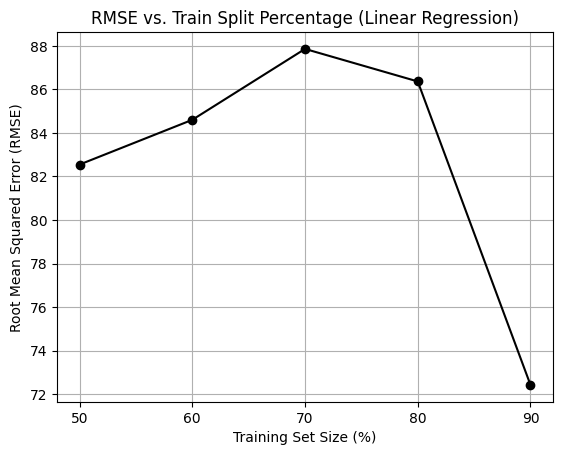

,Linear Model Prediction,True Labels,Name
0,851.244642,640.0000,Titanic
1,-2.735657,10.0000,Drone Explorer
2,71.118188,60.1331,Clay's Falcon Fighter Blaster
3,1.679549,22.2502,Magical Funfair Stalls
4,183.333055,124.9900,Poe's X-wing Fighter
5,78.598035,15.0000,Mini Trains
6,156.752049,190.0000,Dragon Mountain
7,71.672303,64.9900,Organic Grocery Store
8,5.444774,24.9900,Wolf Legend Beast
9,80.313182,80.0000,Container Heist


In [131]:
# ----------------------------------------------
# Hold-out Validation for Linear Regression (Various Train Sizes)
# ----------------------------------------------

# Train-test split percentages
train_splits = (50, 60, 70, 80, 90)
linear_rmses = []
linear_dfs = []

# Evaluate Linear Regression across multiple train sizes
for perc in train_splits:
    test_ratio = 1 - (perc / 100)
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(pattern, labels, test_size=test_ratio, random_state=42)
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    linear = LinearRegression()
    linear.fit(train, trainlabel)
    test_pred = linear.predict(test)
    test_rmse = np.sqrt(mean_squared_error(testlabel, test_pred))
    linear_rmses.append(test_rmse)

    print(f"[Linear] Train split: {perc}% | Test RMSE: {test_rmse:.4f}")

    linear_df = pd.DataFrame({
        'Linear Model Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    linear_dfs.append(linear_df)

# Plot RMSE vs. train size (Linear)
plt.plot(train_splits, linear_rmses, marker='o', color='black')
plt.title('RMSE vs. Train Split Percentage (Linear Regression)')
plt.xticks(train_splits)
plt.xlabel("Training Set Size (%)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

# Show prediction preview
display(pd.concat(linear_dfs).head(10))

In [132]:
# ----------------------------------------------
# Final Evaluation: Linear Regression (90% Train Split)
# ----------------------------------------------

# Split 90% training / 10% test
trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
    pattern, labels, test_size=0.1, random_state=42
)
train = trains.drop(columns=['Name'])
test = tests.drop(columns=['Name'])

# Fit linear regression model
lr = LinearRegression()
lr.fit(train, trainlabel)
test_pred = lr.predict(test)

# Compute metrics
test_mae = sklearn.metrics.mean_absolute_error(testlabel, test_pred)
test_rmse = np.sqrt(sklearn.metrics.mean_squared_error(testlabel, test_pred))
test_r2 = r2_score(testlabel, test_pred)

# Print results
print(f"\n\n[Linear] Test RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

# Display predictions
lr_df = pd.DataFrame({
    'Linear Regression Prediction': test_pred,
    'True Labels': testlabel,
    'Name': tests.reset_index(drop=True)['Name']
})

display(lr_df.head(10))



[Linear] Test RMSE: 72.4270 | MAE: 41.3295 | R²: 0.7005


,Linear Regression Prediction,True Labels,Name
0,891.228269,640.0000,Titanic
1,-3.797148,10.0000,Drone Explorer
2,70.296108,60.1331,Clay's Falcon Fighter Blaster
3,1.299859,22.2502,Magical Funfair Stalls
4,177.276235,124.9900,Poe's X-wing Fighter
5,80.573606,15.0000,Mini Trains
6,165.109515,190.0000,Dragon Mountain
7,68.817264,64.9900,Organic Grocery Store
8,5.249881,24.9900,Wolf Legend Beast
9,88.349864,80.0000,Container Heist


[DTR] Train split: 50% | Test RMSE: 88.4313
[DTR] Train split: 60% | Test RMSE: 89.5568
[DTR] Train split: 70% | Test RMSE: 92.0899
[DTR] Train split: 80% | Test RMSE: 80.8268
[DTR] Train split: 90% | Test RMSE: 63.3798


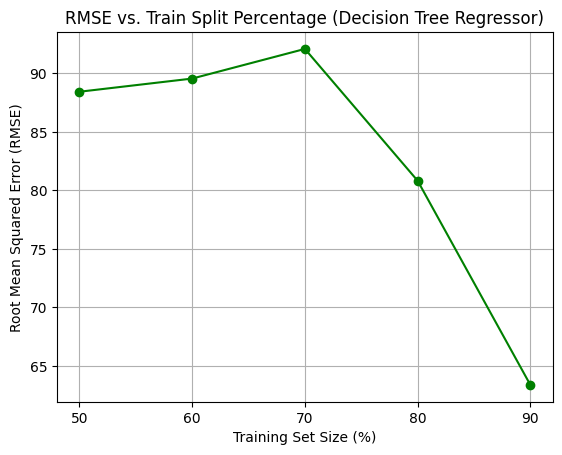

,Decision Tree Prediction,True Labels,Name
0,368.770940,640.0000,Titanic
1,20.346610,10.0000,Drone Explorer
2,91.981524,60.1331,Clay's Falcon Fighter Blaster
3,28.747600,22.2502,Magical Funfair Stalls
4,159.494444,124.9900,Poe's X-wing Fighter
5,23.585349,15.0000,Mini Trains
6,97.688989,190.0000,Dragon Mountain
7,110.938173,64.9900,Organic Grocery Store
8,20.346610,24.9900,Wolf Legend Beast
9,152.143606,80.0000,Container Heist


In [133]:
# ----------------------------------------------
# Hold-out Validation for Decision Tree Regressor (Various Train Sizes)
# ----------------------------------------------

dtr_rmses = []
dtr_dfs = []

for perc in train_splits:
    test_ratio = 1 - (perc / 100)
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
        pattern, labels, test_size=test_ratio, random_state=42
    )
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    dtr = DecisionTreeRegressor(max_depth=6, min_samples_split=5, min_samples_leaf=5)
    dtr.fit(train, trainlabel)
    test_pred = dtr.predict(test)
    test_rmse = np.sqrt(sklearn.metrics.mean_squared_error(testlabel, test_pred))
    dtr_rmses.append(test_rmse)
    print(f"[DTR] Train split: {perc}% | Test RMSE: {test_rmse:.4f}")

    dtr_df = pd.DataFrame({
        'Decision Tree Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    dtr_dfs.append(dtr_df)

plt.plot(train_splits, dtr_rmses, marker='o', color='green')
plt.title('RMSE vs. Train Split Percentage (Decision Tree Regressor)')
plt.xticks(train_splits)
plt.xlabel("Training Set Size (%)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

display(pd.concat(dtr_dfs).head(10))

[DTR] max_depth: 2 | RMSE: 99.8543 | MAE: 52.6390 | R²: 0.4308
[DTR] max_depth: 3 | RMSE: 81.0163 | MAE: 44.0819 | R²: 0.6253
[DTR] max_depth: 4 | RMSE: 69.2260 | MAE: 39.2844 | R²: 0.7264
[DTR] max_depth: 5 | RMSE: 66.3580 | MAE: 37.2527 | R²: 0.7486
[DTR] max_depth: 6 | RMSE: 63.3798 | MAE: 34.8939 | R²: 0.7707
[DTR] max_depth: 7 | RMSE: 59.0294 | MAE: 33.1857 | R²: 0.8011
[DTR] max_depth: 8 | RMSE: 60.6626 | MAE: 32.7459 | R²: 0.7899
[DTR] max_depth: 9 | RMSE: 60.9737 | MAE: 32.8301 | R²: 0.7878
[DTR] max_depth: 10 | RMSE: 60.5149 | MAE: 32.1534 | R²: 0.7910
[DTR] max_depth: 11 | RMSE: 60.8337 | MAE: 32.4431 | R²: 0.7887
[DTR] max_depth: 12 | RMSE: 60.9457 | MAE: 32.4838 | R²: 0.7880
[DTR] max_depth: 13 | RMSE: 61.5001 | MAE: 32.9854 | R²: 0.7841
[DTR] max_depth: 14 | RMSE: 61.5147 | MAE: 32.9874 | R²: 0.7840
[DTR] max_depth: 15 | RMSE: 61.5287 | MAE: 33.0239 | R²: 0.7839
[DTR] max_depth: 16 | RMSE: 61.5339 | MAE: 32.9655 | R²: 0.7839
[DTR] max_depth: 17 | RMSE: 61.5259 | MAE: 32.94

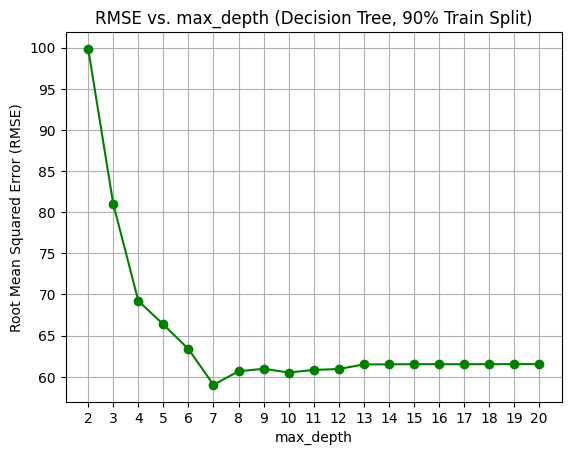

,Decision Tree Prediction,True Labels,Name
0,248.956257,640.0000,Titanic
1,35.489056,10.0000,Drone Explorer
2,98.923141,60.1331,Clay's Falcon Fighter Blaster
3,35.489056,22.2502,Magical Funfair Stalls
4,98.923141,124.9900,Poe's X-wing Fighter
5,35.489056,15.0000,Mini Trains
6,98.923141,190.0000,Dragon Mountain
7,248.956257,64.9900,Organic Grocery Store
8,35.489056,24.9900,Wolf Legend Beast
9,35.489056,80.0000,Container Heist


In [134]:
# ----------------------------------------------
# Decision Tree Regressor: Varying max_depth
# ----------------------------------------------

max_depths = list(range(2, 21))
dtr_rmses_depth = []
dtr_maes_depth = []
dtr_r2s_depth = []
dtr_dfs = []

for depth in max_depths:
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
        pattern, labels, test_size=0.1, random_state=42
    )
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    dtr = DecisionTreeRegressor(max_depth=depth, min_samples_split=5, min_samples_leaf=5)
    dtr.fit(train, trainlabel)
    test_pred = dtr.predict(test)

    test_rmse = np.sqrt(mean_squared_error(testlabel, test_pred))
    test_mae = mean_absolute_error(testlabel, test_pred)
    test_r2 = r2_score(testlabel, test_pred)

    dtr_rmses_depth.append(test_rmse)
    dtr_maes_depth.append(test_mae)
    dtr_r2s_depth.append(test_r2)

    print(f"[DTR] max_depth: {depth} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

    dtr_df = pd.DataFrame({
        'Decision Tree Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    dtr_dfs.append(dtr_df)

# Plot RMSE vs max_depth
plt.plot(max_depths, dtr_rmses_depth, marker='o', color='green')
plt.title('RMSE vs. max_depth (Decision Tree, 90% Train Split)')
plt.xticks(max_depths)
plt.xlabel("max_depth")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

display(pd.concat(dtr_dfs).head(10))

[RFR] Train split: 50% | Test RMSE: 70.5037
[RFR] Train split: 60% | Test RMSE: 73.7260
[RFR] Train split: 70% | Test RMSE: 65.5162
[RFR] Train split: 80% | Test RMSE: 70.3359
[RFR] Train split: 90% | Test RMSE: 69.1489


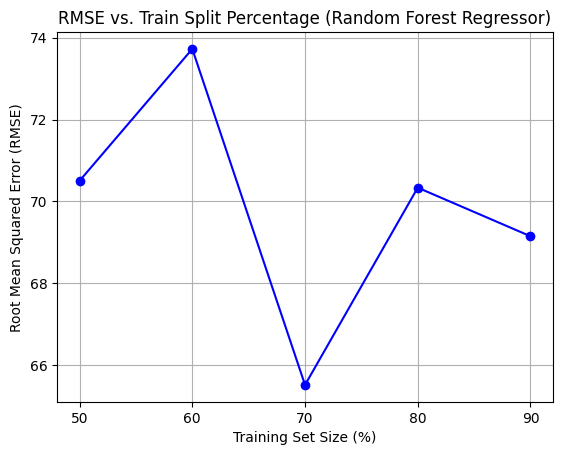

,Random Forest Prediction,True Labels,Name
0,466.443151,640.0000,Titanic
1,19.195287,10.0000,Drone Explorer
2,95.397953,60.1331,Clay's Falcon Fighter Blaster
3,32.164589,22.2502,Magical Funfair Stalls
4,167.258226,124.9900,Poe's X-wing Fighter
5,24.418744,15.0000,Mini Trains
6,167.097329,190.0000,Dragon Mountain
7,92.861363,64.9900,Organic Grocery Store
8,20.360834,24.9900,Wolf Legend Beast
9,114.607213,80.0000,Container Heist


In [135]:
# ----------------------------------------------
# Hold-out Validation for Random Forest Regressor (Various Train Sizes)
# ----------------------------------------------

rfr_rmses = []
rfr_dfs = []

for perc in train_splits:
    test_ratio = 1 - (perc / 100)
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
        pattern, labels, test_size=test_ratio, random_state=42
    )
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    rfr = RandomForestRegressor(max_depth=6, random_state=42)
    rfr.fit(train, trainlabel)
    test_pred = rfr.predict(test)
    test_rmse = np.sqrt(sklearn.metrics.mean_squared_error(testlabel, test_pred))
    rfr_rmses.append(test_rmse)
    print(f"[RFR] Train split: {perc}% | Test RMSE: {test_rmse:.4f}")

    rfr_df = pd.DataFrame({
        'Random Forest Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    rfr_dfs.append(rfr_df)

plt.plot(train_splits, rfr_rmses, marker='o', color='blue')
plt.title('RMSE vs. Train Split Percentage (Random Forest Regressor)')
plt.xticks(train_splits)
plt.xlabel("Training Set Size (%)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

display(pd.concat(rfr_dfs).head(10))

[RFR] Max Depth: 2 | RMSE: 102.5381 | MAE: 50.4780 | R²: 0.4364
[RFR] Max Depth: 3 | RMSE: 83.7813 | MAE: 41.2153 | R²: 0.6237
[RFR] Max Depth: 4 | RMSE: 71.8454 | MAE: 36.5599 | R²: 0.7233
[RFR] Max Depth: 5 | RMSE: 67.5906 | MAE: 33.7982 | R²: 0.7551
[RFR] Max Depth: 6 | RMSE: 65.5162 | MAE: 32.1686 | R²: 0.7699
[RFR] Max Depth: 7 | RMSE: 65.0036 | MAE: 31.3730 | R²: 0.7735
[RFR] Max Depth: 8 | RMSE: 65.2786 | MAE: 30.8406 | R²: 0.7716
[RFR] Max Depth: 9 | RMSE: 66.0900 | MAE: 30.7155 | R²: 0.7658
[RFR] Max Depth: 10 | RMSE: 65.4906 | MAE: 30.5075 | R²: 0.7701
[RFR] Max Depth: 11 | RMSE: 64.9245 | MAE: 30.3675 | R²: 0.7740
[RFR] Max Depth: 12 | RMSE: 65.7115 | MAE: 30.2825 | R²: 0.7685
[RFR] Max Depth: 13 | RMSE: 65.3068 | MAE: 30.1017 | R²: 0.7714
[RFR] Max Depth: 14 | RMSE: 66.0491 | MAE: 30.1687 | R²: 0.7661
[RFR] Max Depth: 15 | RMSE: 65.3114 | MAE: 30.0345 | R²: 0.7713


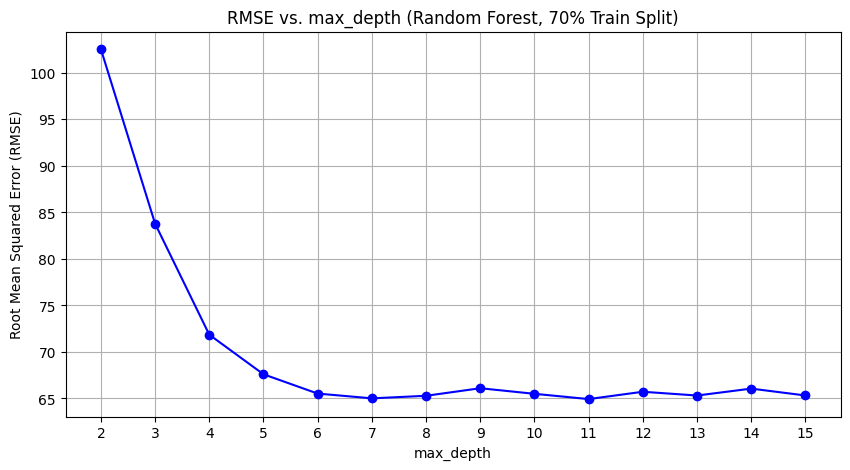

,Random Forest Prediction,True Labels,Name
0,258.975365,640.0000,Titanic
1,40.446464,10.0000,Drone Explorer
2,90.049326,60.1331,Clay's Falcon Fighter Blaster
3,57.677555,22.2502,Magical Funfair Stalls
4,93.599712,124.9900,Poe's X-wing Fighter
5,40.446464,15.0000,Mini Trains
6,90.049326,190.0000,Dragon Mountain
7,214.999968,64.9900,Organic Grocery Store
8,40.446464,24.9900,Wolf Legend Beast
9,55.080053,80.0000,Container Heist


In [136]:
# ----------------------------------------------
# Random Forest Regressor: Varying max_depth
# ----------------------------------------------

rfr_rmses_depth = []
rfr_maes_depth = []
rfr_r2s_depth = []
rfr_dfs_depth = []
rfr_max_depths = list(range(2, 16))

for depth in rfr_max_depths:
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
        pattern, labels, test_size=0.3, random_state=42  # 70% train
    )
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    rfr = RandomForestRegressor(max_depth=depth, random_state=42)
    rfr.fit(train, trainlabel)
    test_pred = rfr.predict(test)

    test_rmse = np.sqrt(mean_squared_error(testlabel, test_pred))
    test_mae = mean_absolute_error(testlabel, test_pred)
    test_r2 = r2_score(testlabel, test_pred)

    rfr_rmses_depth.append(test_rmse)
    rfr_maes_depth.append(test_mae)
    rfr_r2s_depth.append(test_r2)

    print(f"[RFR] Max Depth: {depth} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

    rfr_df = pd.DataFrame({
        'Random Forest Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    rfr_dfs_depth.append(rfr_df)

# Plot RMSE vs Max Depth
plt.figure(figsize=(10, 5))
plt.plot(rfr_max_depths, rfr_rmses_depth, marker='o', color='blue')
plt.title('RMSE vs. max_depth (Random Forest, 70% Train Split)')
plt.xticks(rfr_max_depths)
plt.xlabel("max_depth")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

# Display prediction preview
display(pd.concat(rfr_dfs_depth).head(10))


[SVR] Train split: 50% | Test RMSE: 104.7476
[SVR] Train split: 60% | Test RMSE: 108.9298
[SVR] Train split: 70% | Test RMSE: 104.0650
[SVR] Train split: 80% | Test RMSE: 102.4410
[SVR] Train split: 90% | Test RMSE: 95.5005


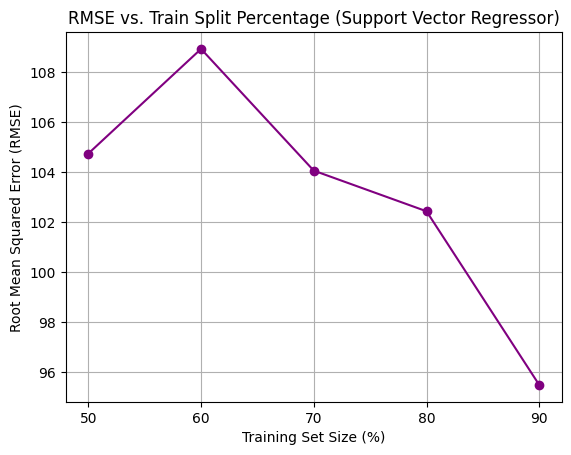

,Support Vector Prediction,True Labels,Name
0,389.488595,640.0000,Titanic
1,23.768927,10.0000,Drone Explorer
2,73.604958,60.1331,Clay's Falcon Fighter Blaster
3,51.548359,22.2502,Magical Funfair Stalls
4,101.923062,124.9900,Poe's X-wing Fighter
5,21.037711,15.0000,Mini Trains
6,58.914901,190.0000,Dragon Mountain
7,115.513514,64.9900,Organic Grocery Store
8,24.432693,24.9900,Wolf Legend Beast
9,45.521591,80.0000,Container Heist


In [137]:
# ----------------------------------------------
# Hold-out Validation for Support Vector Regressor (Various Train Sizes)
# ----------------------------------------------

svr_rmses = []
svr_dfs = []

for perc in train_splits:
    test_ratio = 1 - (perc / 100)
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
        pattern, labels, test_size=test_ratio, random_state=42
    )
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    svr = SVR(kernel='rbf', C=100, epsilon=10)
    svr.fit(train, trainlabel)
    test_pred = svr.predict(test)
    test_rmse = np.sqrt(sklearn.metrics.mean_squared_error(testlabel, test_pred))
    svr_rmses.append(test_rmse)
    print(f"[SVR] Train split: {perc}% | Test RMSE: {test_rmse:.4f}")

    svr_df = pd.DataFrame({
        'Support Vector Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    svr_dfs.append(svr_df)

plt.plot(train_splits, svr_rmses, marker='o', color='purple')
plt.title('RMSE vs. Train Split Percentage (Support Vector Regressor)')
plt.xticks(train_splits)
plt.xlabel("Training Set Size (%)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

display(pd.concat(svr_dfs).head(10))


In [138]:
# ----------------------------------------------
# Final Evaluation: Support Vector Regressor (90% Train Split)
# ----------------------------------------------

# 90% training split
trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
    pattern, labels, test_size=0.1, random_state=42
)
train = trains.drop(columns=['Name'])
test = tests.drop(columns=['Name'])

# SVR model with preset parameters
svr = SVR(kernel='rbf', C=100, epsilon=10)
svr.fit(train, trainlabel)
test_pred = svr.predict(test)

# Evaluation metrics
test_rmse = np.sqrt(mean_squared_error(testlabel, test_pred))
test_mae = mean_absolute_error(testlabel, test_pred)
test_r2 = r2_score(testlabel, test_pred)

# Output results
print(f"[SVR] Test RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

[SVR] Test RMSE: 95.5005 | MAE: 46.9756 | R²: 0.4794


[GBR] Train split: 50% | Test RMSE: 76.6023
[GBR] Train split: 60% | Test RMSE: 75.6262
[GBR] Train split: 70% | Test RMSE: 72.1935
[GBR] Train split: 80% | Test RMSE: 77.7695
[GBR] Train split: 90% | Test RMSE: 68.2905


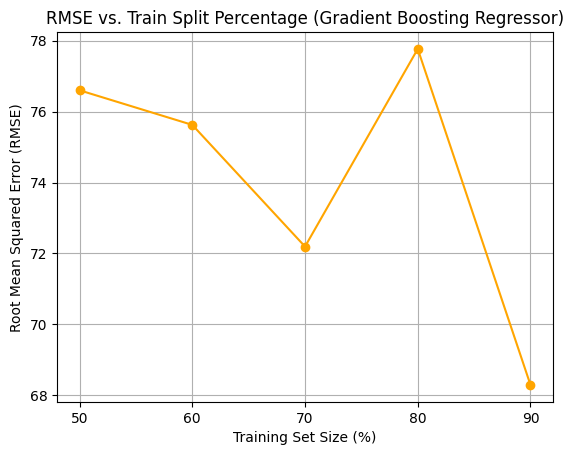

,Gradient Boosting Prediction,True Labels,Name
0,440.440164,640.0000,Titanic
1,13.701320,10.0000,Drone Explorer
2,88.173241,60.1331,Clay's Falcon Fighter Blaster
3,25.393578,22.2502,Magical Funfair Stalls
4,188.776260,124.9900,Poe's X-wing Fighter
5,12.656850,15.0000,Mini Trains
6,108.673457,190.0000,Dragon Mountain
7,42.769635,64.9900,Organic Grocery Store
8,9.992405,24.9900,Wolf Legend Beast
9,150.895850,80.0000,Container Heist


In [139]:
# ----------------------------------------------
# Hold-out Validation for Gradient Boosting Regressor (Various Train Sizes)
# ----------------------------------------------

gbr_rmses = []
gbr_dfs = []

for perc in train_splits:
    test_ratio = 1 - (perc / 100)
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
        pattern, labels, test_size=test_ratio, random_state=42
    )
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    gbr = HistGradientBoostingRegressor(max_iter=100, learning_rate=0.1, max_depth=6, random_state=42)
    gbr.fit(train, trainlabel)
    test_pred = gbr.predict(test)
    test_rmse = np.sqrt(sklearn.metrics.mean_squared_error(testlabel, test_pred))
    gbr_rmses.append(test_rmse)
    print(f"[GBR] Train split: {perc}% | Test RMSE: {test_rmse:.4f}")

    gbr_df = pd.DataFrame({
        'Gradient Boosting Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    gbr_dfs.append(gbr_df)

plt.plot(train_splits, gbr_rmses, marker='o', color='orange')
plt.title('RMSE vs. Train Split Percentage (Gradient Boosting Regressor)')
plt.xticks(train_splits)
plt.xlabel("Training Set Size (%)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

display(pd.concat(gbr_dfs).head(10))

[GBR] max_iter: 10 | RMSE: 75.8867 | MAE: 43.7899 | R²: 0.6713
[GBR] max_iter: 20 | RMSE: 60.9994 | MAE: 34.7771 | R²: 0.7876
[GBR] max_iter: 30 | RMSE: 59.2072 | MAE: 32.7536 | R²: 0.7999
[GBR] max_iter: 40 | RMSE: 61.0375 | MAE: 32.9129 | R²: 0.7873
[GBR] max_iter: 50 | RMSE: 62.9684 | MAE: 33.2254 | R²: 0.7737
[GBR] max_iter: 60 | RMSE: 64.5799 | MAE: 33.5223 | R²: 0.7619
[GBR] max_iter: 70 | RMSE: 66.2955 | MAE: 33.7655 | R²: 0.7491
[GBR] max_iter: 80 | RMSE: 66.8938 | MAE: 33.8877 | R²: 0.7446
[GBR] max_iter: 90 | RMSE: 68.0475 | MAE: 34.0514 | R²: 0.7357
[GBR] max_iter: 100 | RMSE: 68.2905 | MAE: 33.9469 | R²: 0.7338
[GBR] max_iter: 110 | RMSE: 69.4654 | MAE: 34.0998 | R²: 0.7245
[GBR] max_iter: 120 | RMSE: 70.0995 | MAE: 34.2253 | R²: 0.7195
[GBR] max_iter: 130 | RMSE: 70.4144 | MAE: 34.3299 | R²: 0.7170
[GBR] max_iter: 140 | RMSE: 71.1242 | MAE: 34.4115 | R²: 0.7112
[GBR] max_iter: 150 | RMSE: 71.6805 | MAE: 34.5459 | R²: 0.7067


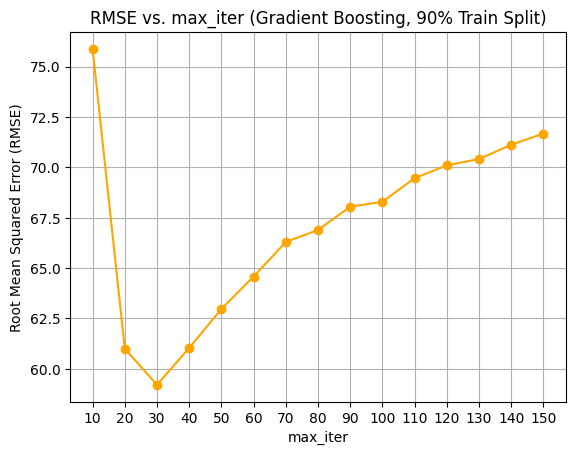

,Gradient Boosting Prediction,True Labels,Name
0,281.497626,640.0000,Titanic
1,43.389782,10.0000,Drone Explorer
2,93.487587,60.1331,Clay's Falcon Fighter Blaster
3,50.078828,22.2502,Magical Funfair Stalls
4,120.342823,124.9900,Poe's X-wing Fighter
5,45.620933,15.0000,Mini Trains
6,104.544184,190.0000,Dragon Mountain
7,82.413354,64.9900,Organic Grocery Store
8,43.389782,24.9900,Wolf Legend Beast
9,112.421696,80.0000,Container Heist


In [140]:
# ----------------------------------------------
# Gradient Boosting Regressor: Varying max_iter
# ----------------------------------------------

gbr_iters = list(range(10, 151, 10))
gbr_rmses_iter = []
gbr_maes_iter = []
gbr_r2s_iter = []
gbr_dfs_iter = []

for iters in gbr_iters:
    trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
        pattern, labels, test_size=0.1, random_state=42
    )
    train = trains.drop(columns=['Name'])
    test = tests.drop(columns=['Name'])

    gbr = HistGradientBoostingRegressor(max_iter=iters, learning_rate=0.1, max_depth=6, random_state=42)
    gbr.fit(train, trainlabel)
    test_pred = gbr.predict(test)

    test_rmse = np.sqrt(mean_squared_error(testlabel, test_pred))
    test_mae = mean_absolute_error(testlabel, test_pred)
    test_r2 = r2_score(testlabel, test_pred)

    gbr_rmses_iter.append(test_rmse)
    gbr_maes_iter.append(test_mae)
    gbr_r2s_iter.append(test_r2)

    print(f"[GBR] max_iter: {iters} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

    gbr_df = pd.DataFrame({
        'Gradient Boosting Prediction': test_pred,
        'True Labels': testlabel,
        'Name': tests.reset_index(drop=True)['Name']
    })
    gbr_dfs_iter.append(gbr_df)

# Plot RMSE vs max_iter
plt.plot(gbr_iters, gbr_rmses_iter, marker='o', color='orange')
plt.title('RMSE vs. max_iter (Gradient Boosting, 90% Train Split)')
plt.xticks(gbr_iters)
plt.xlabel("max_iter")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(True)
plt.show()

# Display prediction preview
display(pd.concat(gbr_dfs_iter).head(10))

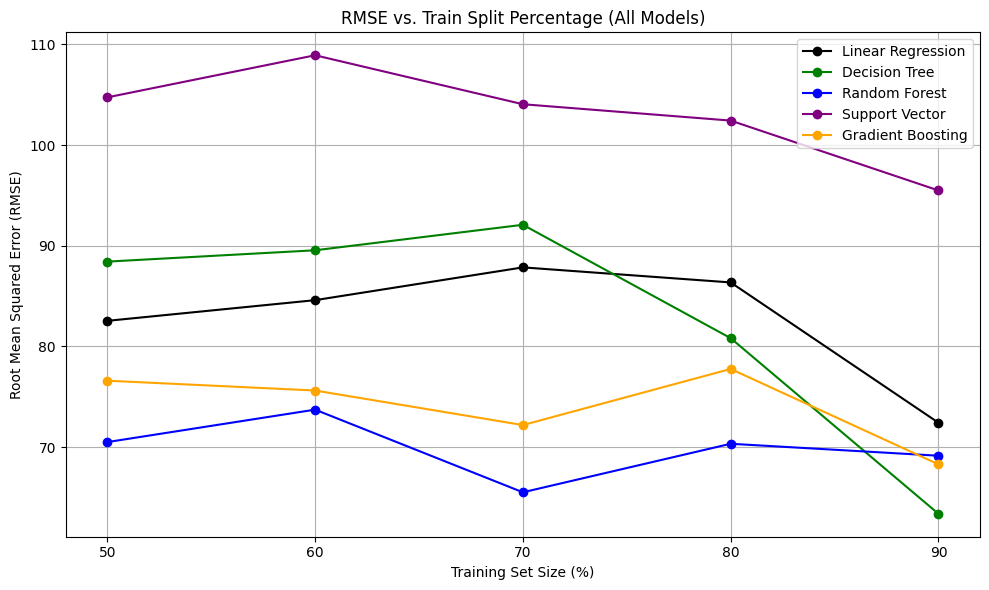

In [141]:
# ----------------------------------------------
# RMSE Comparison Plot for All Models
# ----------------------------------------------

plt.figure(figsize=(10, 6))
plt.plot(train_splits, linear_rmses, marker='o', label='Linear Regression', color='black')
plt.plot(train_splits, dtr_rmses, marker='o', label='Decision Tree', color='green')
plt.plot(train_splits, rfr_rmses, marker='o', label='Random Forest', color='blue')
plt.plot(train_splits, svr_rmses, marker='o', label='Support Vector', color='purple')
plt.plot(train_splits, gbr_rmses, marker='o', label='Gradient Boosting', color='orange')

plt.title('RMSE vs. Train Split Percentage (All Models)')
plt.xlabel("Training Set Size (%)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.xticks(train_splits)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [142]:
# ----------------------------------------------
# Feature Correlation Analysis
# ----------------------------------------------

vectors = data.drop(columns = ['Name', 'Price_per_piece', 'Price_appreciation'])
corrs = vectors.corr()['Current_Price'].drop('Current_Price')
corrs = corrs.reindex(corrs.abs().sort_values(ascending=False).index)
display(corrs)

,Current_Price
USD_MSRP,0.618180
Pieces,0.567148
Theme_Advanced models,0.393533
Year,-0.220335
Theme_Star Wars,0.171511
...,...
Theme_Dino,0.000987
Theme_Space,-0.000684
Theme_Vikings,0.000451
Theme_Harry Potter,-0.000393


In [143]:
# ----------------------------------------------
# Final Model Performance Summary Table
# ----------------------------------------------

# Define data
data = {
    "Model": [
        "Mean Baseline", "Median Baseline", "Gaussian Baseline",
        "Linear Regression",
        "Decision Tree (depth=7)",
        "Random Forest (depth=11)",
        "Gradient Boosting (iter=30)",
        "Support Vector Regressor"
    ],
    "R²": [
        -0.001, -0.199, -1.508,
        0.7005,
        0.8011,
        0.7740,
        0.7999,
        0.4794
    ],
    "MAE": [
        72.914, 72.975, 140.425,
        41.3295,
        33.1857,
        30.3675,
        32.7536,
        46.9756
    ],
    "RMSE": [
        115.637, 126.575, 183.018,
        72.4270,
        59.0294,
        64.9245,
        59.2072,
        95.5005
    ]
}

# Create and display table
df = pd.DataFrame(data)
df = df[["Model", "R²", "MAE", "RMSE"]]  # ensure column order
df.style.set_caption("Model Performance Comparison")

,Model,R²,MAE,RMSE
0,Mean Baseline,-0.001000,72.914000,115.637000
1,Median Baseline,-0.199000,72.975000,126.575000
2,Gaussian Baseline,-1.508000,140.425000,183.018000
3,Linear Regression,0.700500,41.329500,72.427000
4,Decision Tree (depth=7),0.801100,33.185700,59.029400
5,Random Forest (depth=11),0.774000,30.367500,64.924500
6,Gradient Boosting (iter=30),0.799900,32.753600,59.207200
7,Support Vector Regressor,0.479400,46.975600,95.500500


In [144]:
# ----------------------------------------------
# Final Decision Tree Evaluation (Depth = 7)
# ----------------------------------------------

# Use 90% training split
trains, tests, trainlabel, testlabel = sklearn.model_selection.train_test_split(
    pattern, labels, test_size=0.1, random_state=42
)
train = trains.drop(columns=['Name'])
test = tests.drop(columns=['Name'])

# Final Decision Tree model with tuned depth
dtr_final = DecisionTreeRegressor(max_depth=7, min_samples_split=5, min_samples_leaf=5)
dtr_final.fit(train, trainlabel)
final_pred = dtr_final.predict(test)

# Evaluation metrics
test_rmse = np.sqrt(mean_squared_error(testlabel, final_pred))
test_mae = mean_absolute_error(testlabel, final_pred)
test_r2 = r2_score(testlabel, final_pred)

print(f"[Final DTR] RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}")

# Compare predictions to actual values
comparison_df = pd.DataFrame({
    'Predicted Price': final_pred,
    'Actual Price': testlabel,
    'Set Name': tests.reset_index(drop=True)['Name']
})

# Show top 10 comparisons
display(comparison_df.head(10))


[Final DTR] RMSE: 59.0294 | MAE: 33.1857 | R²: 0.8011


,Predicted Price,Actual Price,Set Name
0,456.886667,640.0000,Titanic
1,27.268668,10.0000,Drone Explorer
2,93.962122,60.1331,Clay's Falcon Fighter Blaster
3,29.904049,22.2502,Magical Funfair Stalls
4,122.246591,124.9900,Poe's X-wing Fighter
5,14.530595,15.0000,Mini Trains
6,93.962122,190.0000,Dragon Mountain
7,95.268765,64.9900,Organic Grocery Store
8,27.268668,24.9900,Wolf Legend Beast
9,98.181390,80.0000,Container Heist
